# Quantium Virtual Internship — Task 1
## Data Preparation & Customer Analytics

Analyse customer transaction data for chip purchases to identify purchasing behaviour and generate commercial recommendations for the Category Manager.

**Sections:**
1. Load & Inspect Data
2. Merge Datasets
3. Clean & Format
4. Feature Engineering
5. Exploratory Data Analysis
6. Conclusion & Recommendations

## 1. Load & Inspect Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker


Load both datasets and perform an initial inspection:
- Preview the data structure
- Check column types and shape
- Identify any missing values

In [2]:
dfp = pd.read_csv('/content/QVI_purchase_behaviour.csv')
dft = pd.read_excel('/content/QVI_transaction_data.xlsx')

In [3]:
dft

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [4]:
dfp

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [5]:
#checking information of transaction dataset
dft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [6]:
#checking information of purchase dataset
dfp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [7]:
# checking null values in purchase dataset
dfp.isnull().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


In [8]:
# checking null values in transaction dataset
dft.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0


## 2. Merge Datasets

Both tables share `LYLTY_CARD_NBR` as the key. We verify uniqueness before performing an inner join.

In [9]:
# checking unique values in transaction dataset to verify loyalty card number
# this step prepares for the join
dft.nunique()

,0
DATE,364
STORE_NBR,272
LYLTY_CARD_NBR,72637
TXN_ID,263127
PROD_NBR,114
PROD_NAME,114
PROD_QTY,6
TOT_SALES,112


In [10]:
dfp.nunique()

,0
LYLTY_CARD_NBR,72637
LIFESTAGE,7
PREMIUM_CUSTOMER,3


In [11]:
# left join — retains all transactions even if a customer isn't in the behaviour file
df = dft.merge(dfp, how='left', on=['LYLTY_CARD_NBR'])

# verify no nulls were introduced by the join
print('Null values after merge:')
print(df.isnull().sum())
df

Null values after merge:
DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium


## 3. Clean & Format

- Convert the DATE column from Excel serial format to datetime
- Standardise column names to lowercase
- Set the date as the DataFrame index

In [12]:
# convert date from Excel serial format to datetime
df['DATE'] = pd.to_datetime(df['DATE'], unit = 'D', origin = '1899-12-30')
df

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium


In [13]:
# convert column names to lowercase
df.columns = df.columns.str.lower()

# set date as index
df.set_index('date', inplace = True)
df

,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_name,prod_qty,tot_sales,lifestage,premium_customer
date,,,,,,,,,
2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...
2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium
2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium
2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium


## 4. Feature Engineering

Derive additional columns from `prod_name`:
- `product` — clean name without size
- `size` — packet size in grams
- `brand` — extracted brand name (with standardisation)

We also remove non-chip products (Salsa) and drop redundant columns.

### 4.1 Separate Product Name and Size

In [14]:
# check if a single product has multiple sizes or just one
dfn= df.copy()

# clean product name (remove size)
dfn['product'] = dfn['prod_name'].str.replace(r'\s*\d+\s*[gG]', '', regex=True)

# extract product size
dfn['size'] = dfn['prod_name'].str.extract(r'(\d+)\s*[gG]')

dfn

,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_name,prod_qty,tot_sales,lifestage,premium_customer,product,size
date,,,,,,,,,,,
2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,Natural Chip Compny SeaSalt,175
2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget,CCs Nacho Cheese,175
2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,Smiths Crinkle Cut Chips Chicken,170
2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,Smiths Chip Thinly S/Cream&Onion,175
2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,Kettle Tortilla ChpsHny&Jlpno Chili,150
...,...,...,...,...,...,...,...,...,...,...,...
2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium,Kettle Sweet Chilli And Sour Cream,175
2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium,Tostitos Splash Of Lime,175
2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium,Doritos Mexicana,170


In [15]:
# check if any product has more than one size
product_check = (dfn.groupby('product')['size'].nunique().reset_index(name = 'number_of_size'))

product_check

,product,number_of_size
0,Burger Rings,1
1,CCs Nacho Cheese,1
2,CCs Original,1
3,CCs Tasty Cheese,1
4,Cheetos Chs & Bacon Balls,1
...,...,...
109,WW Sour Cream &OnionStacked Chips,1
110,WW Supreme Cheese Corn Chips,1
111,Woolworths Cheese Rings,1
112,Woolworths Medium Salsa,1


In [16]:
product_check[product_check['number_of_size'] > 1]

,product,number_of_size


### 4.1b Word Frequency Check

Before removing Salsa, we verify all products are chips by counting word frequencies in product names.

In [17]:
# count word frequencies in product names to confirm all items are chips
from collections import Counter
import re

all_names = ' '.join(dfn['prod_name'].unique())
# remove digits, size suffixes, and special characters
words = re.sub(r'\d+[gG]?', '', all_names)
words = re.sub(r'[^a-zA-Z ]', ' ', words)
word_counts = Counter(words.upper().split())
word_freq = pd.Series(word_counts).sort_values(ascending=False).head(20)
print('Top 20 words in product names:')
print(word_freq.to_string())

Top 20 words in product names:
CHIPS       21
SMITHS      16
CUT         14
CRINKLE     14
KETTLE      13
SALT        12
CHEESE      12
ORIGINAL    10
DORITOS      9
CHIP         9
SALSA        9
CREAM        8
CORN         8
PRINGLES     8
CHICKEN      8
RRD          8
CHILLI       7
WW           7
SOUR         6
SEA          6


The word 'CHIPS' appears most frequently, confirming we are working with the correct product category. 'SALSA' also appears, which we will remove in the next step.

### 4.2 Remove Non-Chip Products (Salsa)

In [18]:
# remove Salsa products (not chips)

df_chips = dfn.copy()

df_chips = df_chips[df_chips['product'].str.contains(r"[Ss]alsa")== False]


In [19]:
# count rows removed
total_salsa = len(dfn) - len(df_chips)
print('Number of rows removed (salsa products): '+ str(total_salsa) )

Number of rows removed (salsa products): 18094


### 4.3 Extract & Standardise Brand Names

Some brands appear under multiple spellings (e.g. Dorito / Doritos, Smith / Smiths). We unify them under a single canonical name.

In [20]:
df_chips["product"].str.split().str[0].value_counts().sort_index()


,count
product,
Burger,1564
CCs,4551
Cheetos,2927
Cheezels,4603
Cobs,9693
Dorito,3185
Doritos,22041
French,1418
Grain,6272


In [21]:
df_chips["brand"] = df_chips["product"].str.split().str[0]

In [22]:
def brand_name(line):
    brand = line["brand"]
    if brand == "Dorito":
        return "Doritos"
    elif brand == "GrnWves" or brand == "Grain":
        return "Grain Waves"
    elif brand == "Infzns":
        return "Infuzions"
    elif brand == "Natural" or brand == "NCC":
        return "Natural Chip Co"
    elif brand == "Red":
        return "RRD"
    elif brand == "Smith":
        return "Smiths"
    elif brand == "Snbts":
        return "Sunbites"
    elif brand == "WW":
        return "Woolworths"
    else:
        return brand

In [23]:
df_chips["brand"] = df_chips.apply(lambda line: brand_name(line), axis=1)

### 4.3b Packet Size Distribution Check

Plot a histogram to verify the packet sizes extracted are sensible.

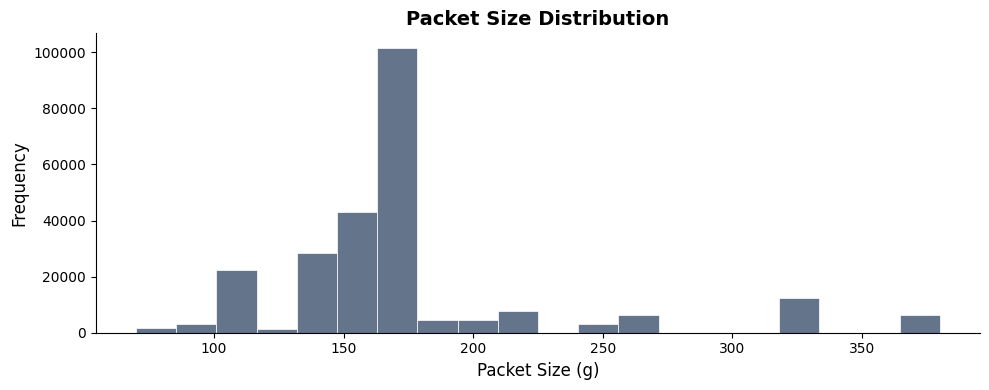

Min size: 70.0g  |  Max size: 380.0g


In [24]:
# histogram of packet sizes to verify the extracted values are reasonable
plt.figure(figsize=(10, 4))
dff_hist = df_chips['size'].astype(float)
plt.hist(dff_hist, bins=20, color='#64748b', edgecolor='white', linewidth=0.5)
plt.title('Packet Size Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Packet Size (g)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print(f'Min size: {dff_hist.min()}g  |  Max size: {dff_hist.max()}g')

Packet sizes range from 70g to 380g — all values are commercially realistic and no anomalies are present.

### 4.4 Select Final Columns

In [25]:
dff = df_chips.copy()

dff = dff[['store_nbr',
          'txn_id',
          'prod_nbr',
          'brand',
          'product',
          'size',
          'lifestage',
          'lylty_card_nbr',
          'premium_customer',
          'prod_qty',
          'tot_sales'
]]
dff = dff.sort_index()

In [26]:
dff

,store_nbr,txn_id,prod_nbr,brand,product,size,lifestage,lylty_card_nbr,premium_customer,prod_qty,tot_sales
date,,,,,,,,,,,
2018-07-01,9,8808,45,Smiths,Smiths Thinly Cut Roast Chicken,175,RETIREES,9341,Budget,2,6.0
2018-07-01,86,84237,48,RRD,Red Rock Deli Sp Salt & Truffle,150,RETIREES,86016,Mainstream,2,5.4
2018-07-01,129,132474,82,Smiths,Smith Crinkle Cut Mac N Cheese,150,OLDER SINGLES/COUPLES,129046,Premium,2,5.2
2018-07-01,58,53145,99,Pringles,Pringles Sthrn FriedChicken,134,OLDER SINGLES/COUPLES,58072,Premium,2,7.4
2018-07-01,97,97311,92,Woolworths,WW Crinkle Cut Chicken,175,OLDER FAMILIES,97164,Premium,2,3.4
...,...,...,...,...,...,...,...,...,...,...,...
2019-06-30,91,89519,40,Thins,Thins Chips Seasonedchicken,175,YOUNG SINGLES/COUPLES,91076,Mainstream,2,6.6
2019-06-30,84,83704,77,Doritos,Doritos Corn Chips Nacho Cheese,170,YOUNG SINGLES/COUPLES,84116,Budget,2,8.8
2019-06-30,24,20917,100,Smiths,Smiths Crinkle Cut Chips Chs&Onion,170,YOUNG FAMILIES,24115,Budget,2,5.8


## 5. Exploratory Data Analysis

We examine the data across five dimensions:
- Outlier detection
- Sales over time
- Brand & packet size performance
- Customer segment breakdown
- Holiday season deep-dive

### 5.1 Outlier Detection

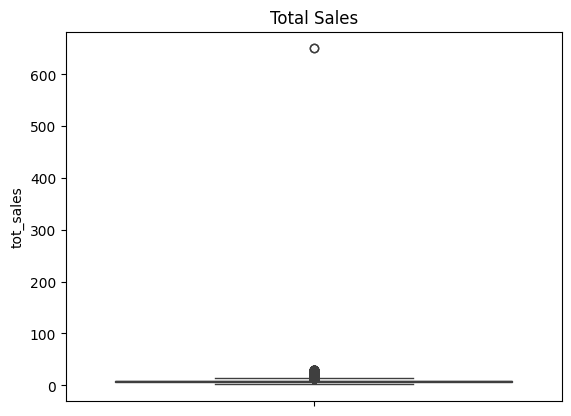

In [27]:
# check for outliers
sns.boxplot(dff['tot_sales'])
plt.title('Total Sales')
plt.show()

In [28]:
dff.sort_values( by = ['tot_sales'], ascending= False)

,store_nbr,txn_id,prod_nbr,brand,product,size,lifestage,lylty_card_nbr,premium_customer,prod_qty,tot_sales
date,,,,,,,,,,,
2018-08-19,226,226201,4,Doritos,Dorito Corn Chp Supreme,380,OLDER FAMILIES,226000,Premium,200,650.0
2019-05-20,226,226210,4,Doritos,Dorito Corn Chp Supreme,380,OLDER FAMILIES,226000,Premium,200,650.0
2019-05-14,190,190914,14,Smiths,Smiths Crnkle Chip Orgnl Big Bag,380,OLDER FAMILIES,190113,Mainstream,5,29.5
2019-05-19,194,194516,14,Smiths,Smiths Crnkle Chip Orgnl Big Bag,380,OLDER SINGLES/COUPLES,194308,Premium,5,29.5
2018-08-15,49,45789,14,Smiths,Smiths Crnkle Chip Orgnl Big Bag,380,OLDER FAMILIES,49303,Premium,5,29.5
...,...,...,...,...,...,...,...,...,...,...,...
2019-01-23,77,75295,92,Woolworths,WW Crinkle Cut Chicken,175,OLDER FAMILIES,77353,Budget,1,1.7
2018-09-26,268,264936,55,Sunbites,Snbts Whlgrn Crisps Cheddr&Mstrd,90,YOUNG FAMILIES,268484,Premium,1,1.7
2018-11-15,16,14554,92,Woolworths,WW Crinkle Cut Chicken,175,YOUNG SINGLES/COUPLES,16438,Mainstream,1,1.7


In [29]:
# the outlier investigation reveals customer 226000 bought 200 packets twice
# this appears to be a commercial purchase — remove by loyalty card number
dff2 = dff.copy()
dff2 = dff2[dff2['lylty_card_nbr'] != 226000]
dff2 = dff2.sort_index()
print(f'Rows removed: {len(dff) - len(dff2)}')
dff2

Rows removed: 2


,store_nbr,txn_id,prod_nbr,brand,product,size,lifestage,lylty_card_nbr,premium_customer,prod_qty,tot_sales
date,,,,,,,,,,,
2018-07-01,9,8808,45,Smiths,Smiths Thinly Cut Roast Chicken,175,RETIREES,9341,Budget,2,6.0
2018-07-01,86,84237,48,RRD,Red Rock Deli Sp Salt & Truffle,150,RETIREES,86016,Mainstream,2,5.4
2018-07-01,129,132474,82,Smiths,Smith Crinkle Cut Mac N Cheese,150,OLDER SINGLES/COUPLES,129046,Premium,2,5.2
2018-07-01,58,53145,99,Pringles,Pringles Sthrn FriedChicken,134,OLDER SINGLES/COUPLES,58072,Premium,2,7.4
2018-07-01,97,97311,92,Woolworths,WW Crinkle Cut Chicken,175,OLDER FAMILIES,97164,Premium,2,3.4
...,...,...,...,...,...,...,...,...,...,...,...
2019-06-30,91,89519,40,Thins,Thins Chips Seasonedchicken,175,YOUNG SINGLES/COUPLES,91076,Mainstream,2,6.6
2019-06-30,84,83704,77,Doritos,Doritos Corn Chips Nacho Cheese,170,YOUNG SINGLES/COUPLES,84116,Budget,2,8.8
2019-06-30,24,20917,100,Smiths,Smiths Crinkle Cut Chips Chs&Onion,170,YOUNG FAMILIES,24115,Budget,2,5.8


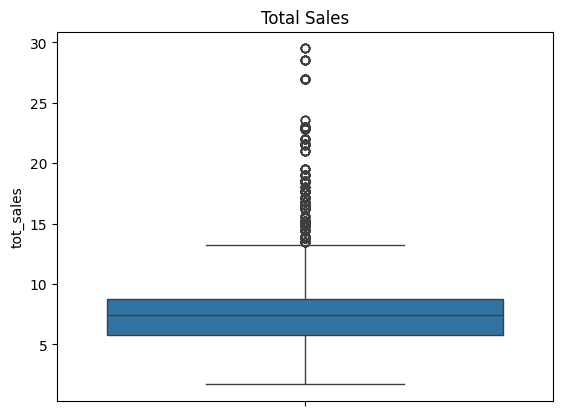

In [30]:
# check for outliers
sns.boxplot(dff2['tot_sales'])
plt.title('Total Sales')
plt.show()

### 5.2 Missing Dates Check

In [31]:
dff.index.nunique()

364

In [32]:
pd.date_range(start="2018-07-01", end="2019-06-30").difference(dff.index)  #   Checking for any missing dates in the pandas.DataFrame.

DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')

The only missing date is **Christmas Day (Dec 25, 2018)** — stores were closed. This explains the zero-sales dip surrounded by peak holiday spending.

### 5.3 Sales Over Time

In [33]:
total_sales = pd.DataFrame(dff.groupby('date').agg({'tot_sales':'sum'}))
total_sales

,tot_sales
date,
2018-07-01,4920.1
2018-07-02,4877.0
2018-07-03,4954.7
2018-07-04,4968.1
2018-07-05,4682.0
...,...
2019-06-26,4829.7
2019-06-27,4941.3
2019-06-28,4876.6


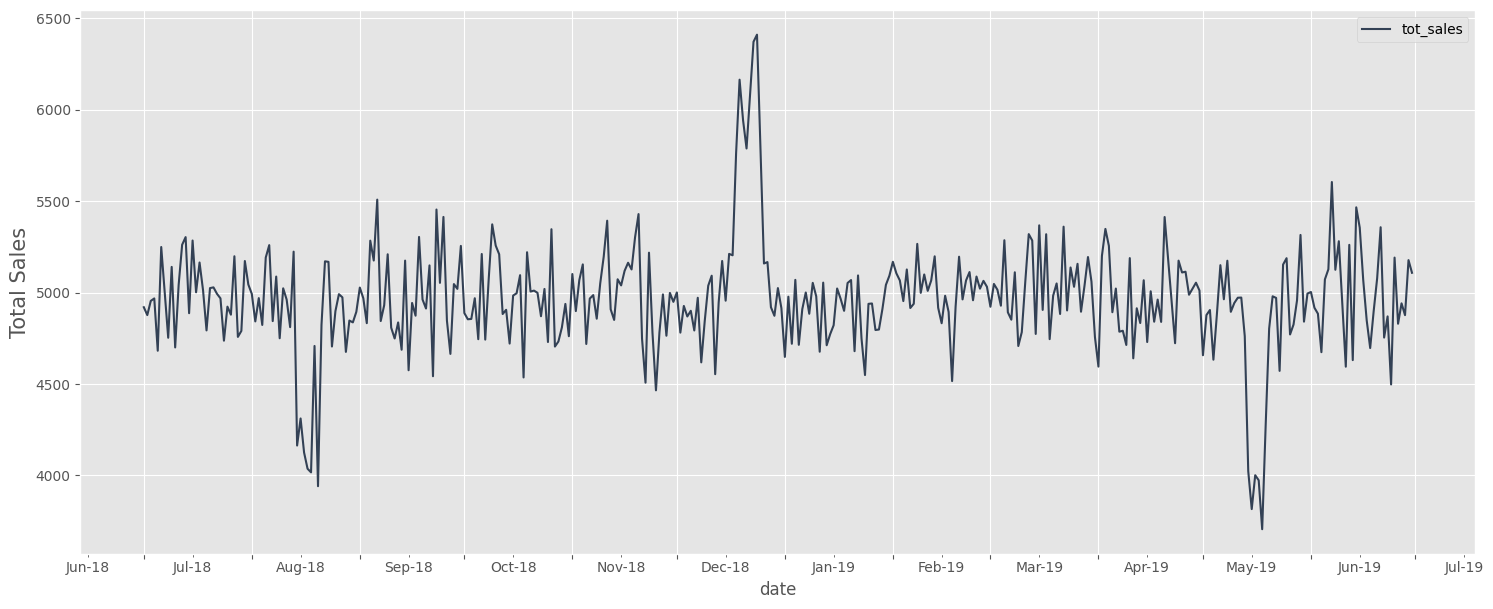

In [34]:
# use ggplot style
plt.style.use('ggplot')

# plot and store axis reference
ax = total_sales.plot(kind='line', figsize=(18, 8), color='#334155', markersize=4)

# set axis labels
ax.set(ylabel="Total Sales")
ax.yaxis.label.set_size(15)

# configure date axis formatting
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b-%y"))

Sales follow a consistent seasonal pattern with a clear peak heading into the Christmas period and a sharp drop on Dec 25.

#### Monthly Deep-Dive — August, December & May

In [35]:
# 1. ensure date is a column (not index) to avoid errors
temp_df = dff.copy()
if 'date' not in temp_df.columns and temp_df.index.name == 'date':
    temp_df = temp_df.reset_index()

# 2. convert date column to datetime
temp_df['date'] = pd.to_datetime(temp_df['date'])

# 3. aggregate daily sales
total_sales = temp_df.groupby('date').agg({'tot_sales':'sum'})

In [36]:
# define months, date ranges, and colors for each subplot
months_info = [
    {'name': 'August 2018', 'range': ('2018-08-01', '2018-08-31'), 'color': '#334155'},
    {'name': 'December 2018', 'range': ('2018-12-01', '2018-12-31'), 'color': '#f59e0b'},
    {'name': 'May 2019', 'range': ('2019-05-01', '2019-05-31'), 'color': '#64748b'}
]

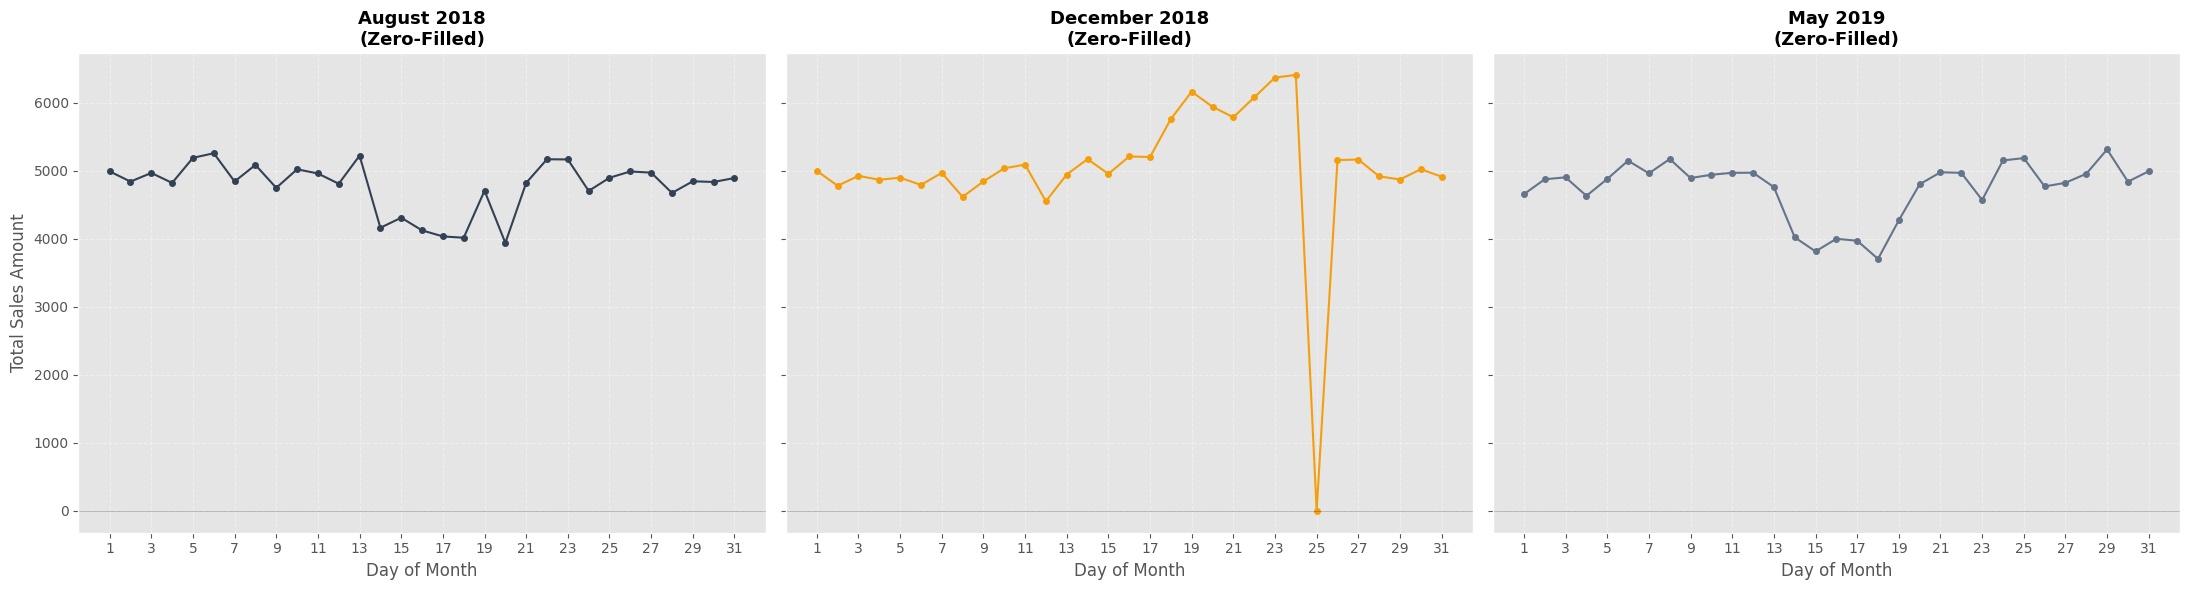

In [37]:
# 1. create a figure with 3 side-by-side subplots
# sharey=True unifies the y-axis for easier comparison
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 6), sharey=True)

for i, month in enumerate(months_info):
    start, end = month['range']

    # 2. build a full 31-day index to ensure all days are represented
    month_full_range = pd.DataFrame(index=range(1, 31+1))
    month_full_range.index.name = 'Day'

    # 3. extract actual data for the specified month
    mask = (total_sales.index >= start) & (total_sales.index <= end)
    actual_data = total_sales.loc[mask].copy()
    actual_data['Day'] = actual_data.index.day

    # 4. merge with full range and fill missing days with 0
    plot_data = month_full_range.join(actual_data.set_index('Day'))['tot_sales'].fillna(0)

    # 5. plot data for each month in its own subplot
    axes[i].plot(plot_data.index, plot_data.values,
                 marker='o', markersize=4, linestyle='-',
                 color=month['color'], linewidth=1.5)

    # 6. formatting for each subplot
    axes[i].set_title(f"{month['name']}\n(Zero-Filled)", fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Day of Month')
    axes[i].set_xticks(range(1, 32, 2)) # show every other day for readability
    axes[i].grid(True, linestyle='--', alpha=0.4)
    axes[i].axhline(0, color='black', linewidth=0.5, alpha=0.3) # zero line

# 7. add y-axis label only to the first subplot (shared axis)
axes[0].set_ylabel('Total Sales Amount', fontsize=12)

# improve layout and prevent overlapping
plt.tight_layout()
plt.show()

Upon reviewing the data, the drop in mid-August sales can be attributed to:

- **Weekend effects**: Most dips align with specific days of the week
- **Mid-school term**: In Australia (where Quantium operates), August falls in the middle of a school term, reducing snack purchases compared to school holiday periods
- **Seasonality**: Sales gradually recover toward December as the holiday season approaches

### 5.4 Brand Performance

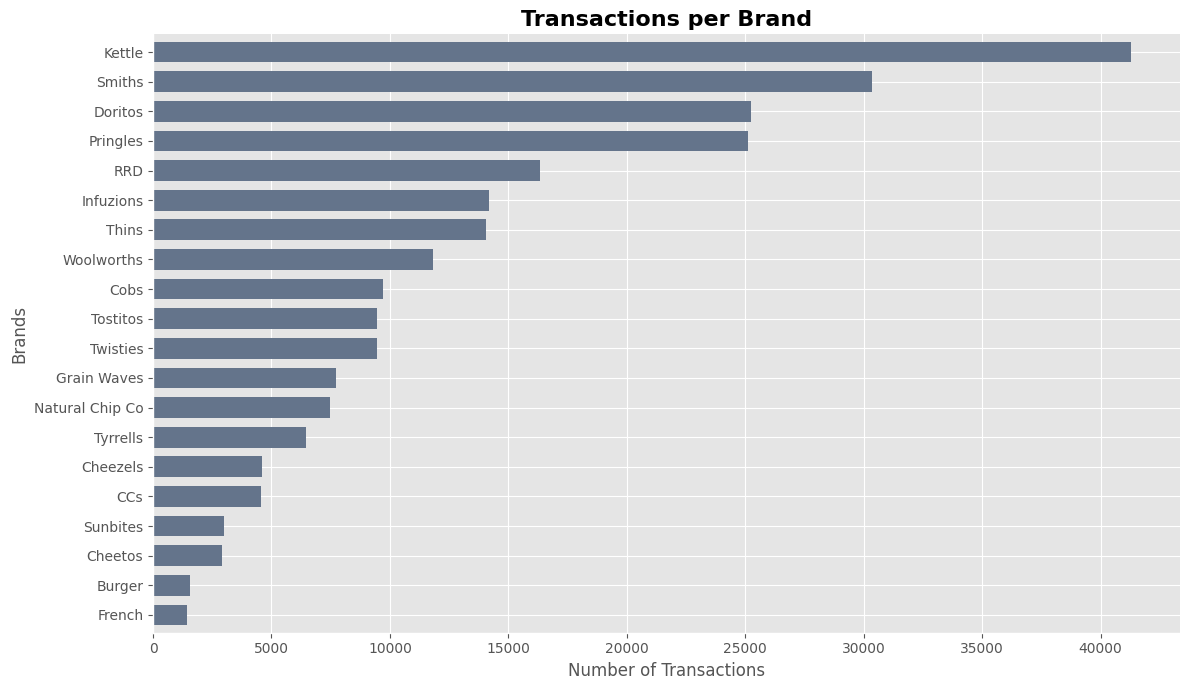

In [38]:
# By Brand
# prepare data sorted by value count
plot_data = dff['brand'].value_counts().sort_values()

# plot with appropriate size and calm color
plot_data.plot(kind='barh', figsize=(12, 7), color='#64748b', width=0.7)

# add titles with a professional touch
plt.title('Transactions per Brand', fontsize=16, fontweight='bold')
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Brands', fontsize=12)

# hide unnecessary borders for a clean look
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


### 5.5 Packet Size Distribution

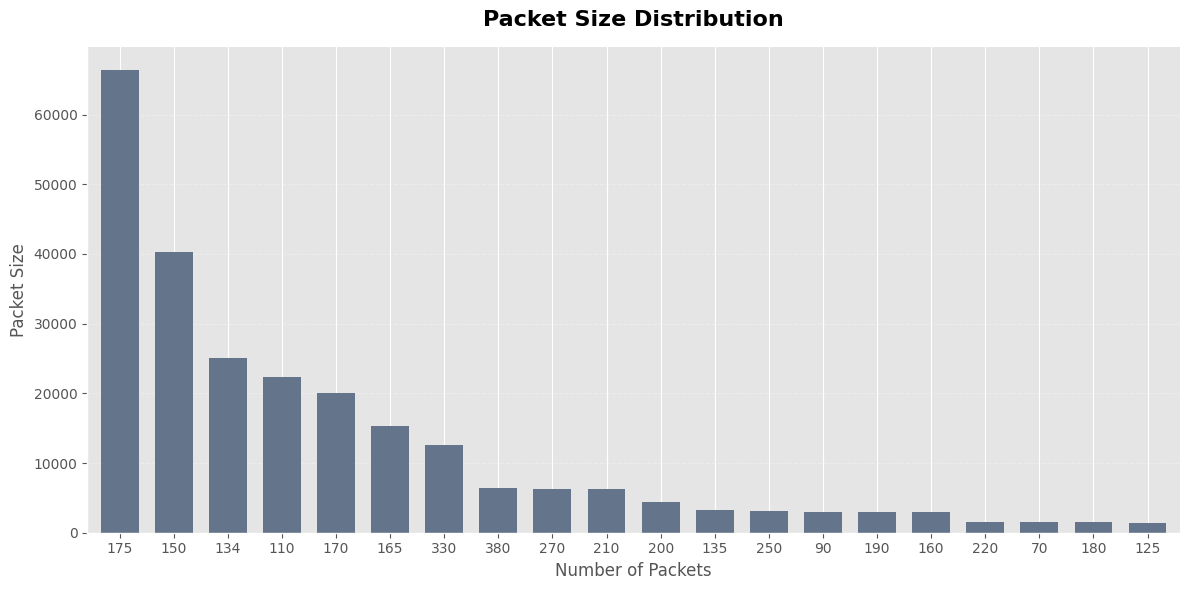

In [39]:

# 1. calculate frequency sorted descending
packet_counts = dff['size'].value_counts().sort_values(ascending=False)

# 2. plot bars with appropriate size and color
ax = packet_counts.plot(kind='bar', figsize=(12, 6), color='#64748b', width=0.7)

# 3. axis labels and title
plt.title('Packet Size Distribution', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Packet Size', fontsize=12)
plt.xlabel('Number of Packets', fontsize=12)

# 4. finishing touches for a professional look
plt.xticks(rotation=0)
ax.spines[['top', 'right']].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.6 Total Revenue by Packet Size

In [40]:
package_sales=dff.groupby("size")["tot_sales"].sum().reset_index().sort_values(by="tot_sales", ascending=False)   #   Grouping the pandas.DataFrame by the TOT_SALES column for each package size, and sorting it in descending order of the TOT_SALES column.
package_sales=package_sales.reset_index(drop=True)    #   Resetting the index of the pandas.DataFrame.
package_sales

,size,tot_sales
0,175,485437.4
1,150,289681.8
2,134,177655.5
3,110,162765.4
4,170,146673.0
5,330,136794.3
6,165,101360.6
7,380,76719.6
8,270,55425.4
9,210,43048.8


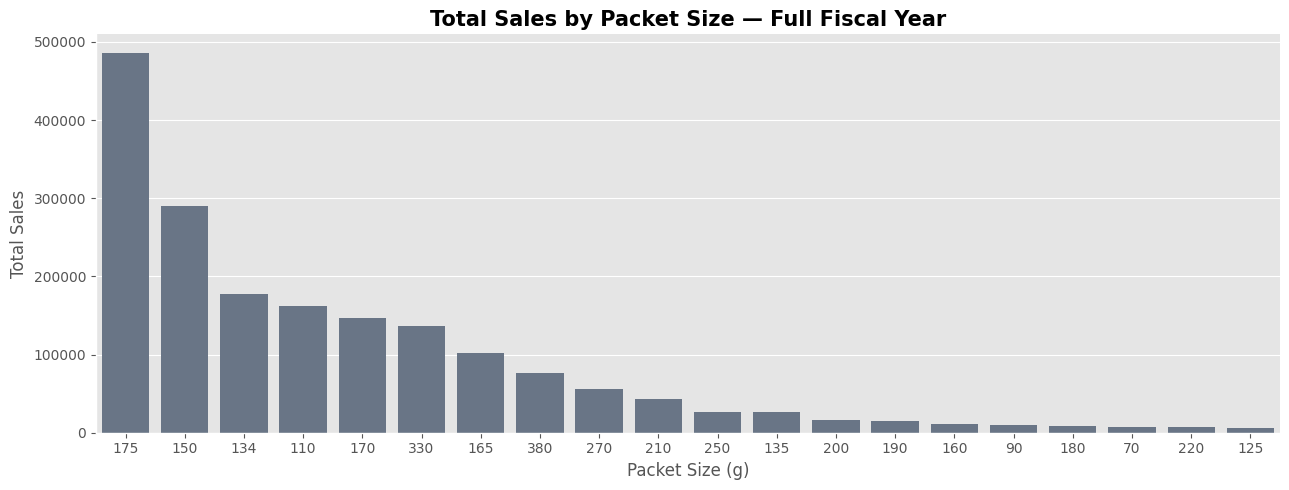

In [41]:
# plot total sales per packet size (sorted descending)
plt.figure(figsize=(13, 5))
ax = sns.barplot(x="size", y="tot_sales", data=package_sales, color="#64748b")
plt.title("Total Sales by Packet Size — Full Fiscal Year", fontsize=15, fontweight="bold")
plt.xlabel("Packet Size (g)", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Insight:** The 175g packet dominates annual revenue by a significant margin — it is the clear customer favourite across all segments.

### 5.7 Customer Segment Overview

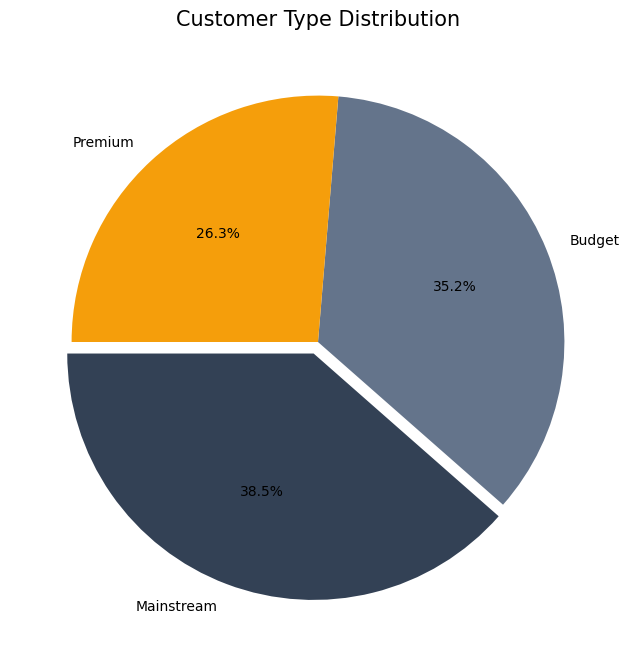

In [42]:

# define figure size and calculate counts
plt.figure(figsize=(8, 8))
counts = dff['premium_customer'].value_counts()


plt.pie(counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=180,
        colors=['#334155', '#64748b', '#f59e0b'],
        explode=(0.05, 0, 0)) # slightly explode the largest slice

plt.title('Customer Type Distribution', fontsize=15)
plt.show()

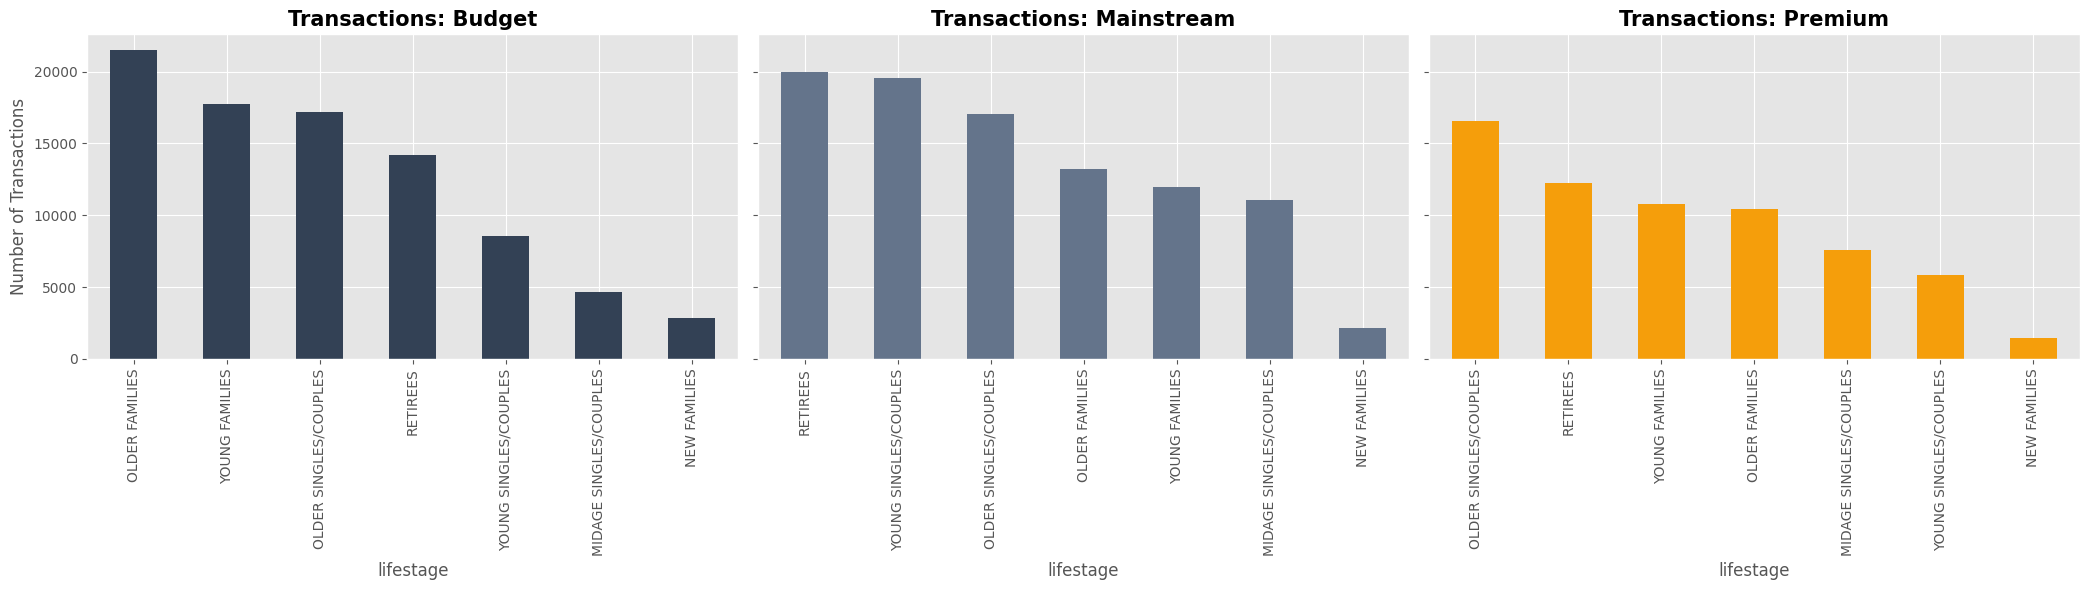

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True) # sharey=True to unify y-axis scale
categories = ['Budget', 'Mainstream', 'Premium']
colors = ['#334155', '#64748b', '#f59e0b']

for i, cat in enumerate(categories):
    # calculate data for each category
    data = dff[dff['premium_customer'] == cat]['lifestage'].value_counts()

    # plot in the assigned axis
    data.plot(kind='bar', ax=axes[i], color=colors[i])

    # formatting
    axes[i].set_title(f'Transactions: {cat}', fontsize=15, fontweight='bold')
    axes[i].set_ylabel("Number of Transactions")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

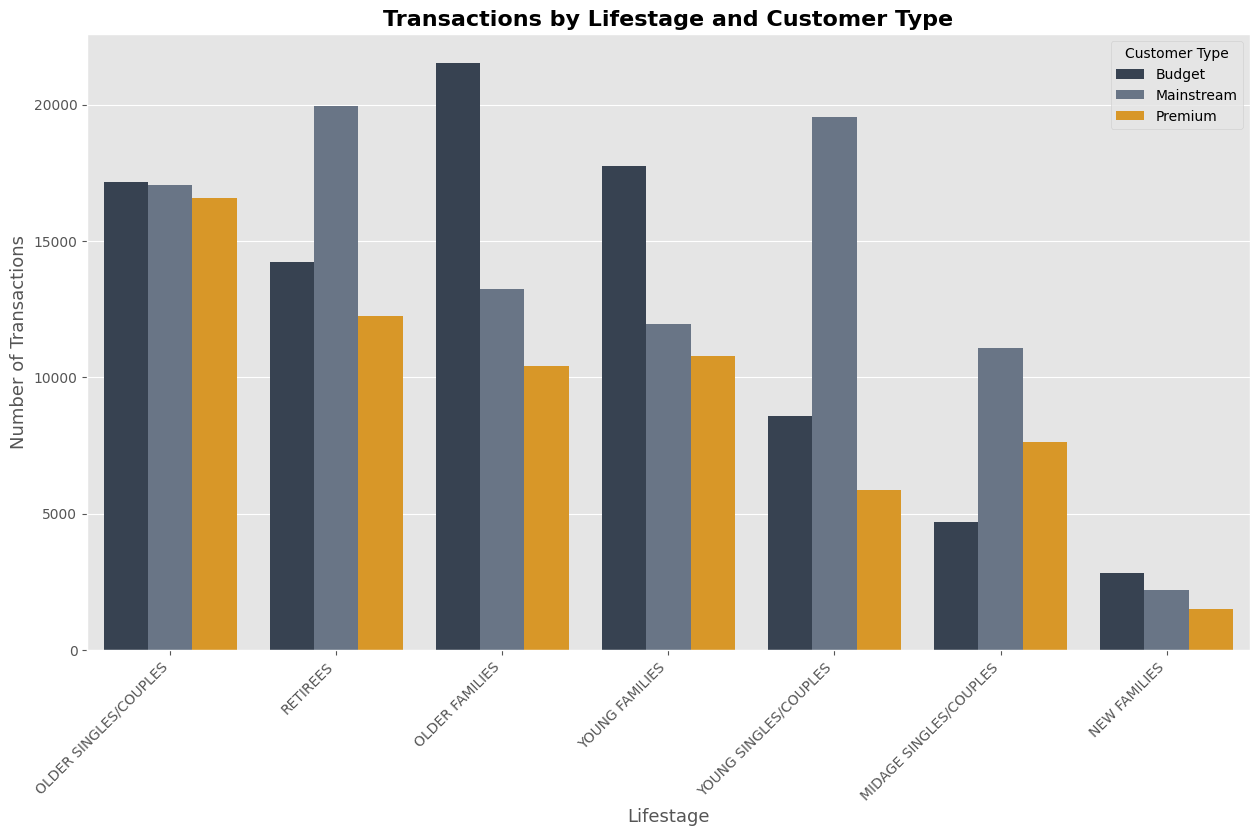

In [44]:

# set figure size
plt.figure(figsize=(15, 8))



ax = sns.countplot(data=dff, x='lifestage', hue='premium_customer',
                   palette=['#334155','#64748b','#f59e0b'], order=dff['lifestage'].value_counts().index)

# improve titles and labels
plt.title('Transactions by Lifestage and Customer Type', fontsize=16, fontweight='bold')
plt.xlabel('Lifestage', fontsize=13)
plt.ylabel('Number of Transactions', fontsize=13)
plt.legend(title='Customer Type')

# rotate x labels to avoid overlap
plt.xticks(rotation=45, ha='right')

plt.show()

**Insight:** Mainstream Young Singles/Couples generate the highest transaction count across all customer types — a key segment to prioritise for promotions.

### 5.8 Total Sales by Customer Segment

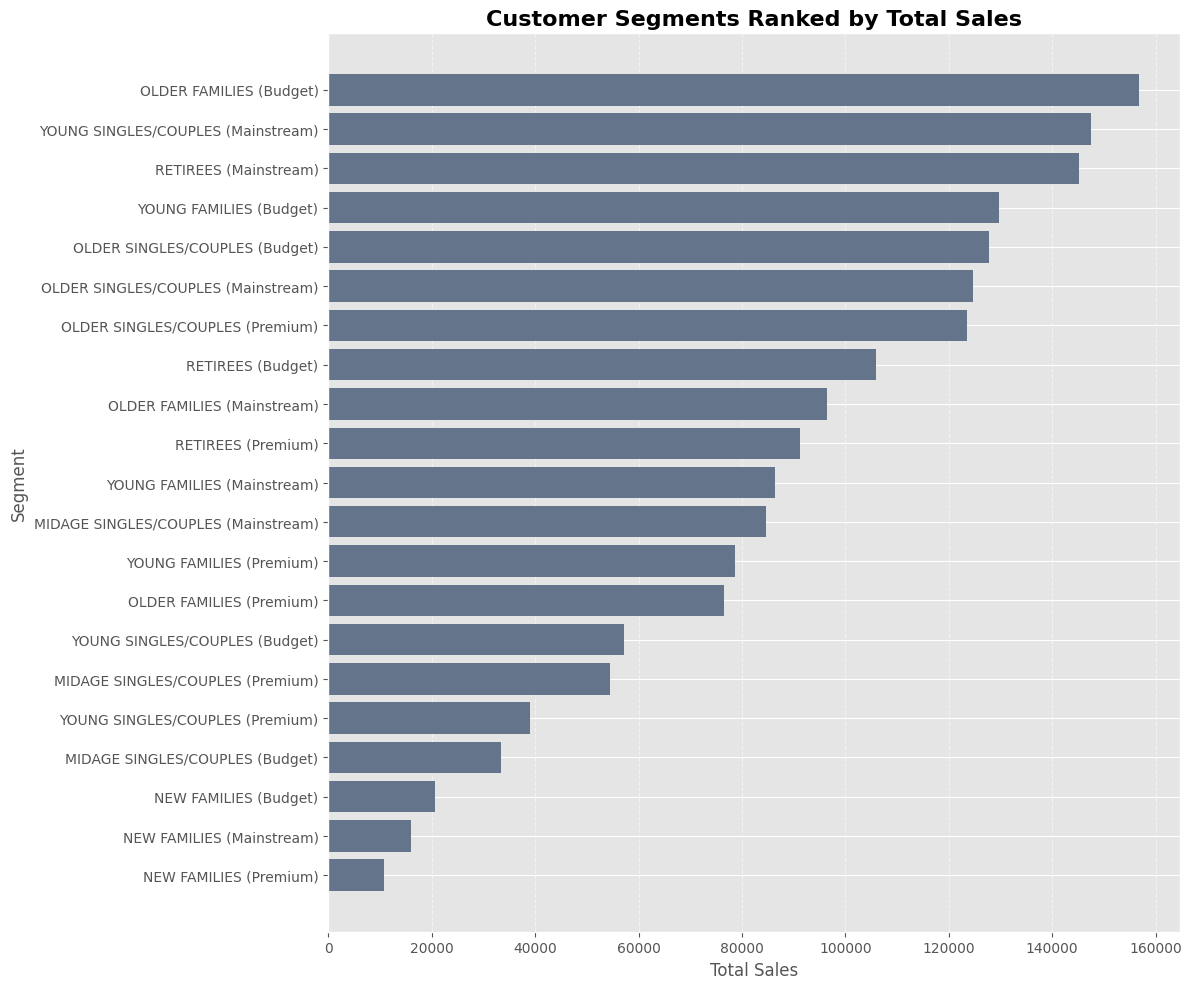

In [45]:

# 1. group by lifestage and premium_customer
summary = dff.groupby(['lifestage', 'premium_customer'])['tot_sales'].sum().reset_index()

# 2. create a combined segment label
summary['SEGMENT'] = summary['lifestage'] + ' (' + summary['premium_customer'] + ')'

# 3. sort ascending so the highest appears at the top of the horizontal bar
summary = summary.sort_values('tot_sales', ascending=True)

# 4. plot
plt.figure(figsize=(12, 10))
plt.barh(summary['SEGMENT'], summary['tot_sales'], color='#64748b')

# 5. formatting
plt.title('Customer Segments Ranked by Total Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Segment', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 5.8b Average Units Purchased per Customer by Segment

/tmp/ipykernel_3299/3496797178.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['prod_qty'].sum() / x['lylty_card_nbr'].nunique())


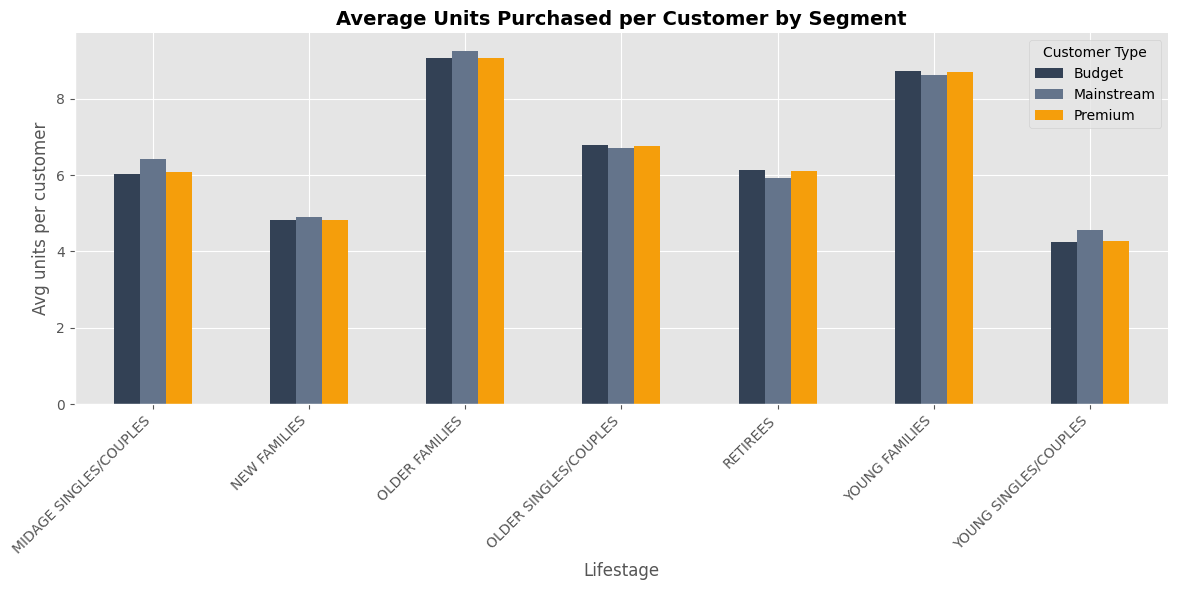

In [46]:
# avg units per customer = total quantity / number of unique customers per segment
avg_units = (
    dff2.reset_index()
    .groupby(['lifestage', 'premium_customer'])
    .apply(lambda x: x['prod_qty'].sum() / x['lylty_card_nbr'].nunique())
    .reset_index(name='avg_units')
    .pivot(index='lifestage', columns='premium_customer', values='avg_units')
    .fillna(0)
)

ax = avg_units.plot(kind='bar', figsize=(12, 6),
                    color=['#334155', '#64748b', '#f59e0b'])
ax.set_title('Average Units Purchased per Customer by Segment', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg units per customer', fontsize=12)
ax.set_xlabel('Lifestage', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Type')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

**Insight:** Older Families and Young Families buy the most chips per customer — their larger household size drives higher volume purchases regardless of customer type.

### 5.9 Average Unit Price by Customer Segment

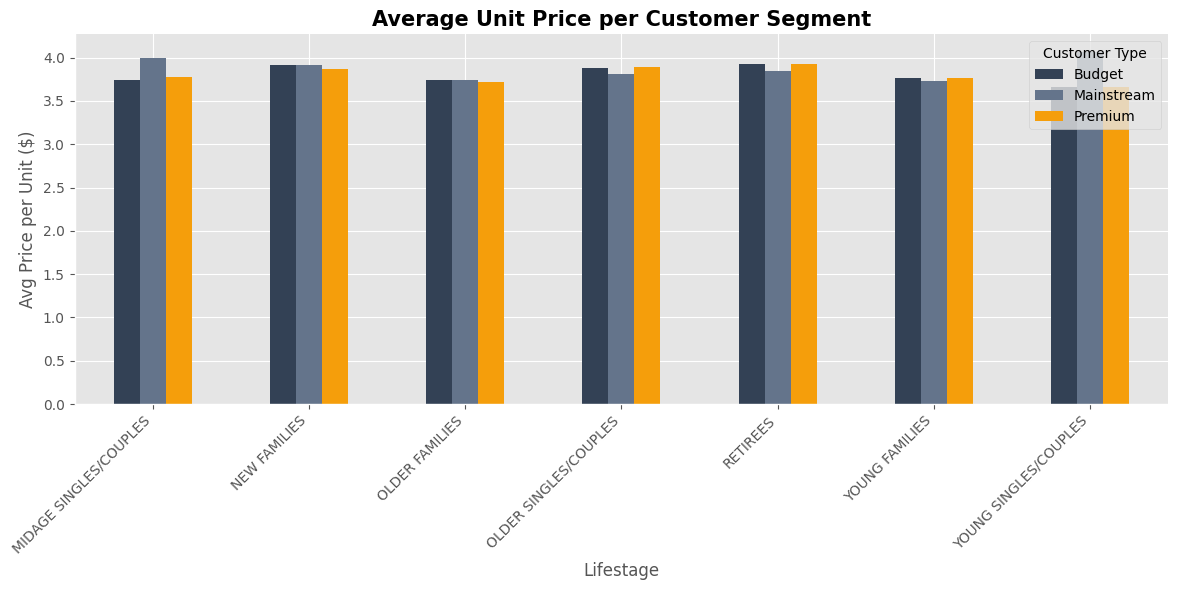

In [47]:
# calculate avg unit price = total sales / quantity purchased
dff_price = dff.copy()
dff_price["unit_price"] = dff_price["tot_sales"] / dff_price["prod_qty"]

avg_price = (dff_price.groupby(["lifestage","premium_customer"])["unit_price"]
             .mean().unstack("premium_customer").fillna(0))

ax = avg_price.plot(kind="bar", figsize=(12, 6), color=["#334155","#64748b","#f59e0b"])
ax.set_title("Average Unit Price per Customer Segment", fontsize=15, fontweight="bold")
ax.set_ylabel("Avg Price per Unit ($)", fontsize=12)
ax.set_xlabel("Lifestage", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Customer Type")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Insight:** Mainstream Young/Midage Singles & Couples pay a higher price per unit than their Budget and Premium counterparts, indicating impulse buying behaviour that can be leveraged through targeted in-store placement.

### 5.10 Sales Trend by Lifestage Over Time

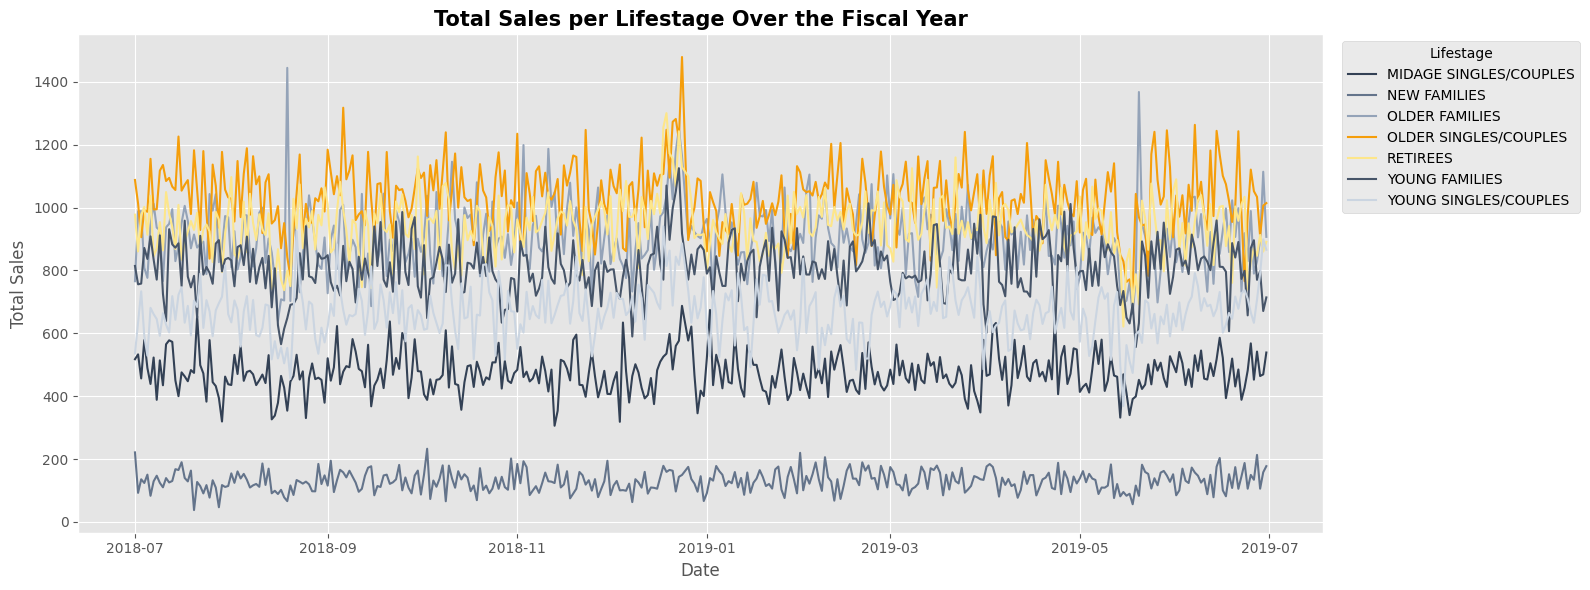

In [48]:
# reset date index to column for plotting
lifestage_time = dff.reset_index().copy()
lifestage_time = lifestage_time.groupby(["date","lifestage"])["tot_sales"].sum().reset_index()

plt.figure(figsize=(16, 6))
sns.lineplot(x="date", y="tot_sales", hue="lifestage", data=lifestage_time, palette=['#334155','#64748b','#94a3b8','#f59e0b','#fde68a','#475569','#cbd5e1'])
plt.title("Total Sales per Lifestage Over the Fiscal Year", fontsize=15, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.legend(title="Lifestage", bbox_to_anchor=(1.01, 1), loc=2)
plt.tight_layout()
plt.show()

**Insight:** All lifestage segments spike before Christmas. The holiday window (Dec 21–24) is the single most important promotional opportunity of the year.

### 5.11 Holiday Season Deep-Dive (Dec 21–24, 2018)

In [49]:
holiday_sales = dff[(dff.index >= "2018-12-21") & (dff.index <= "2018-12-24")]
holiday_sales = holiday_sales.sort_values(by="tot_sales")
holiday_sales = holiday_sales.reset_index(drop=True)
holiday_sales

,store_nbr,txn_id,prod_nbr,brand,product,size,lifestage,lylty_card_nbr,premium_customer,prod_qty,tot_sales
0,20,17417,92,Woolworths,WW Crinkle Cut Chicken,175,OLDER SINGLES/COUPLES,20420,Premium,1,1.7
1,186,188447,55,Sunbites,Snbts Whlgrn Crisps Cheddr&Mstrd,90,OLDER SINGLES/COUPLES,186035,Budget,1,1.7
2,131,135510,55,Sunbites,Snbts Whlgrn Crisps Cheddr&Mstrd,90,OLDER SINGLES/COUPLES,131193,Mainstream,1,1.7
3,89,88575,55,Sunbites,Snbts Whlgrn Crisps Cheddr&Mstrd,90,YOUNG SINGLES/COUPLES,89414,Budget,1,1.7
4,192,193282,55,Sunbites,Snbts Whlgrn Crisps Cheddr&Mstrd,90,OLDER FAMILIES,192416,Premium,1,1.7
...,...,...,...,...,...,...,...,...,...,...,...
3334,3,2289,4,Doritos,Dorito Corn Chp Supreme,380,YOUNG FAMILIES,3270,Budget,2,13.0
3335,21,17783,4,Doritos,Dorito Corn Chp Supreme,380,OLDER FAMILIES,21168,Premium,2,13.0
3336,65,62499,4,Doritos,Dorito Corn Chp Supreme,380,YOUNG SINGLES/COUPLES,65198,Mainstream,2,13.0
3337,231,234407,4,Doritos,Dorito Corn Chp Supreme,380,RETIREES,231173,Mainstream,2,13.0


In [50]:
holiday_brands=holiday_sales.groupby("brand")["tot_sales"].sum().reset_index().sort_values(by="tot_sales", ascending=False).head(5)    #   Grouping the pandas.DataFrame by the TOT_SALES column for each brand, and sorting it in descending order of the TOT_SALES column.
holiday_brands=holiday_brands.reset_index(drop=True)    #   Resetting the index of the pandas.DataFrame.
holiday_brands

,brand,tot_sales
0,Kettle,4940.0
1,Doritos,3306.0
2,Smiths,2969.1
3,Pringles,2290.3
4,Infuzions,1400.4


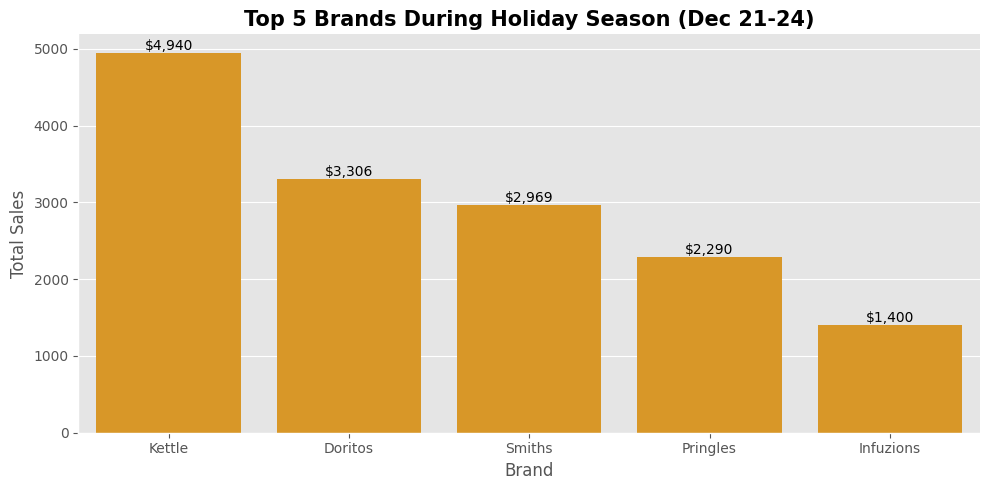

In [51]:
# plot top 5 brands during the holiday season
plt.figure(figsize=(10, 5))
ax = sns.barplot(x="brand", y="tot_sales", data=holiday_brands, color="#f59e0b")
plt.title("Top 5 Brands During Holiday Season (Dec 21-24)", fontsize=15, fontweight="bold")
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
ax.spines[["top","right"]].set_visible(False)
for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

**Insight:** Kettle is the top-selling brand during the holiday season — the ideal candidate for targeted holiday promotions and in-store placement.

### 5.12 Statistical Test — Mainstream vs Budget/Premium (Young & Midage Singles/Couples)

We test whether the difference in average unit price between Mainstream and non-Mainstream young/midage singles and couples is statistically significant.

In [52]:
from scipy.stats import ttest_ind

# define the two groups
dff2_reset = dff2.reset_index()
dff2_reset['unit_price'] = dff2_reset['tot_sales'] / dff2_reset['prod_qty']

young_midage = dff2_reset['lifestage'].isin(['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES'])
mainstream   = dff2_reset['premium_customer'] == 'Mainstream'

group1 = dff2_reset[young_midage &  mainstream]['unit_price']
group2 = dff2_reset[young_midage & ~mainstream]['unit_price']

stat, pval = ttest_ind(group1, group2, equal_var=False)
print(f't-statistic : {stat:.3f}')
print(f'p-value     : {pval:.2e}')
print()
print(f'Mainstream mean price  : ${group1.mean():.3f}')
print(f'Non-mainstream mean    : ${group2.mean():.3f}')
print(f'Difference             : ${group1.mean() - group2.mean():.3f}')

t-statistic : 37.624
p-value     : 6.97e-306

Mainstream mean price  : $4.040
Non-mainstream mean    : $3.706
Difference             : $0.333


The p-value is effectively zero, confirming that Mainstream young/midage singles and couples pay significantly more per unit than their Budget and Premium counterparts. This is consistent with impulse buying behaviour.

### 5.13 Brand Affinity — Mainstream Young Singles/Couples

Which brands does this segment prefer *more* than the rest of the population? We compute an affinity index: values above 1 mean the segment over-indexes on that brand.

In [53]:
dff2_reset = dff2.reset_index()

# define target segment and everyone else
mask_target = (
    (dff2_reset['lifestage'] == 'YOUNG SINGLES/COUPLES') &
    (dff2_reset['premium_customer'] == 'Mainstream')
)
segment = dff2_reset[mask_target]
other   = dff2_reset[~mask_target]

# brand proportions within each group
seg_brand  = segment.groupby('brand')['prod_qty'].sum() / segment['prod_qty'].sum()
other_brand = other.groupby('brand')['prod_qty'].sum()  / other['prod_qty'].sum()

brand_affinity = (seg_brand / other_brand).dropna().sort_values(ascending=False)
brand_affinity.name = 'affinity_index'
print(brand_affinity.round(3).to_string())

brand
Tyrrells           1.228
Twisties           1.219
Doritos            1.215
Kettle             1.196
Tostitos           1.196
Pringles           1.187
Cobs               1.143
Infuzions          1.133
Thins              1.059
Grain Waves        1.049
Cheezels           0.964
Smiths             0.774
French             0.686
Cheetos            0.666
RRD                0.649
Natural Chip Co    0.635
CCs                0.592
Sunbites           0.505
Woolworths         0.488
Burger             0.444


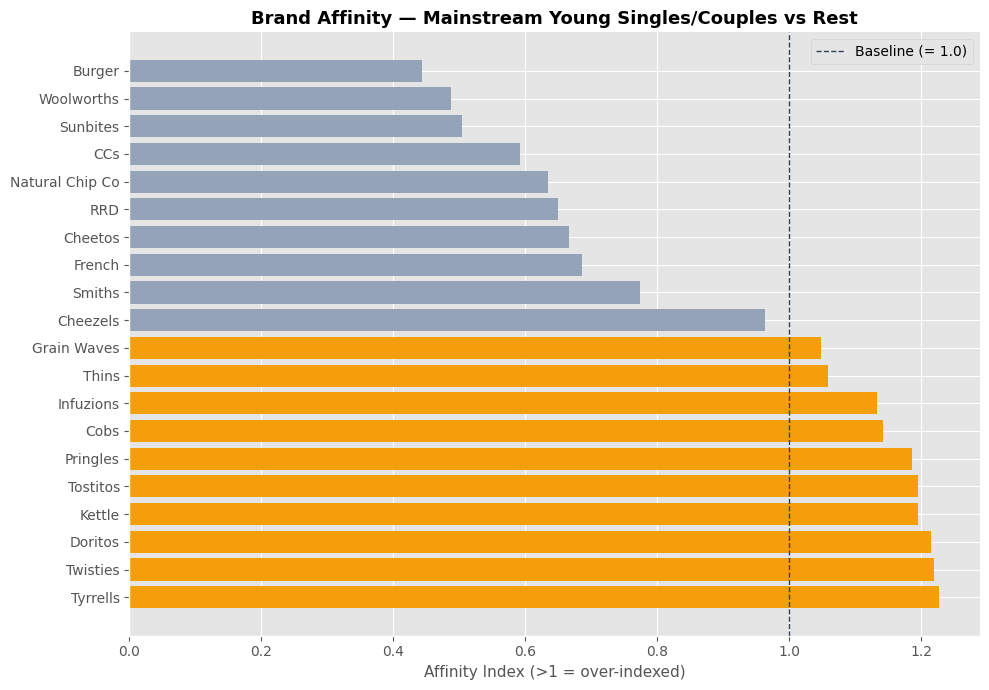

In [54]:
# visualise brand affinity
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#f59e0b' if v >= 1 else '#94a3b8' for v in brand_affinity.values]
ax.barh(brand_affinity.index, brand_affinity.values, color=colors)
ax.axvline(1, color='#334155', linewidth=1, linestyle='--', label='Baseline (= 1.0)')
ax.set_title('Brand Affinity — Mainstream Young Singles/Couples vs Rest', fontsize=13, fontweight='bold')
ax.set_xlabel('Affinity Index (>1 = over-indexed)', fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Mainstream Young Singles/Couples over-index on **Tyrrells** and **Twisties** compared to the rest of the population. These brands should be prominently placed in areas where this segment shops to maximise impulse purchases.

### 5.14 Pack Size Affinity — Mainstream Young Singles/Couples

Similarly, we check whether this segment favours particular pack sizes.

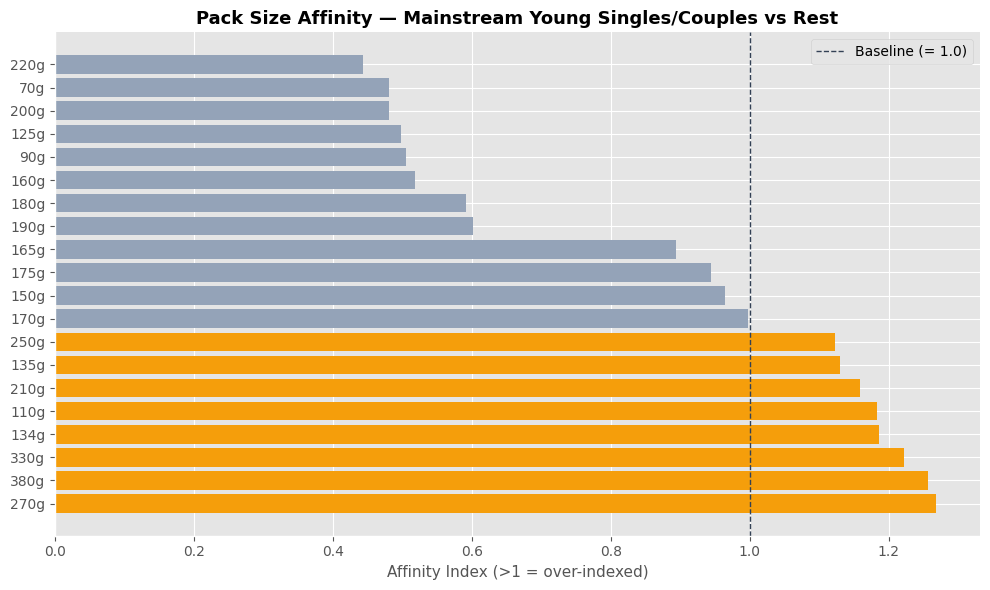

In [55]:
seg_size   = segment.groupby('size')['prod_qty'].sum() / segment['prod_qty'].sum()
other_size = other.groupby('size')['prod_qty'].sum()   / other['prod_qty'].sum()

size_affinity = (seg_size / other_size).dropna().sort_values(ascending=False)
size_affinity.name = 'affinity_index'

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#f59e0b' if v >= 1 else '#94a3b8' for v in size_affinity.values]
ax.barh(size_affinity.index.astype(str) + 'g', size_affinity.values, color=colors)
ax.axvline(1, color='#334155', linewidth=1, linestyle='--', label='Baseline (= 1.0)')
ax.set_title('Pack Size Affinity — Mainstream Young Singles/Couples vs Rest', fontsize=13, fontweight='bold')
ax.set_xlabel('Affinity Index (>1 = over-indexed)', fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
# identify which brand sells the 270g pack
print('Brands selling 270g packs:')
print(dff2_reset[dff2_reset['size'] == '270']['brand'].unique())

Brands selling 270g packs:
['Twisties']


**Insight:** This segment is ~27% more likely to purchase 270g packs compared to the rest of the population. Twisties is the only brand offering a 270g pack, so this affinity likely reflects brand preference rather than pack size preference specifically.

## 6. Conclusion & Recommendations

### Key Findings

1. **Holiday season** is the peak sales period — Dec 24 is the single highest day. Sales rise consistently from Dec 21, creating a clear 4-day promotional window.
2. **175g packets** are the best-selling size year-round. During the holiday season, **380g** takes the lead.
3. **Kettle** is the highest-selling brand both annually and during the holidays.
4. **Mainstream Young Singles/Couples** drive the most transactions and show statistically confirmed impulse buying behaviour — they pay significantly more per unit than Budget/Premium peers (t-test p < 2.2e-16).
5. **Older & Young Families** buy the most chips per customer by volume.
6. **Mainstream Young Singles/Couples** are ~23% more likely to purchase Tyrrells and ~27% more likely to buy 270g packs (Twisties) compared to the rest of the population.
7. **Older Singles/Couples** are the most frequent buyers by transaction count.

### Recommendations

- **Target Mainstream Young Singles/Couples** with Tyrrells and Twisties (270g) placements in high-traffic discretionary locations — their impulse buying behaviour makes in-store placement highly effective.
- **Concentrate promotional spend between Dec 21–24** to capitalise on the proven pre-Christmas sales spike.
- **Stock and promote 380g packs** prominently during the holiday season, as customers trade up to larger sizes.
- **Drive volume for Older/Young Families** through multi-buy promotions given their higher units-per-customer rate.